In [1]:
# general imports
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy as cp

# ase imports
import ase.io
from ase import Atoms, Atom
from ase import units
from ase.build import molecule
# for MD
from ase.md.langevin import Langevin
from ase.io.trajectory import Trajectory
from metatensor.torch.atomistic.ase_calculator import MetatensorCalculator 

In [2]:
def rms_dict(x_ref, x_pred):
    """ Takes two datasets of the same shape and returns a dictionary containing RMS error data"""

    x_ref = np.array(x_ref)
    x_pred = np.array(x_pred)

    if np.shape(x_pred) != np.shape(x_ref):
        raise ValueError('WARNING: not matching shapes in rms')

    error_2 = (x_ref - x_pred) ** 2

    average = np.sqrt(np.average(error_2))
    std_ = np.sqrt(np.var(error_2))

    return {'rmse': average, 'std': std_}

In [3]:
def energy_plot(in_file, out_file, ax, title='Plot of energy'):
    """ Plots the distribution of energy per atom on the output vs the input"""
    # read files
    in_atoms = ase.io.read(in_file, ':')
    out_atoms = ase.io.read(out_file, ':')
    # list energies
    ener_in = [at.get_potential_energy() / len(at.get_chemical_symbols()) for at in in_atoms]
    ener_out = []
    calc = MetatensorCalculator("model.pt", extensions_directory="//home/apaulish/Documents/code/metatrain/dia_si/extensions/") 
    for at in out_atoms:
        at.set_calculator(calc)
        ener_out.append(at.get_potential_energy() / len(at.get_chemical_symbols()))
    # scatter plot of the data
    ax.scatter(ener_in, ener_out)
    # get the appropriate limits for the plot
    for_limits = np.array(ener_in +ener_out)
    elim = (for_limits.min() - 0.05, for_limits.max() + 0.05)
    ax.set_xlim(elim)
    ax.set_ylim(elim)
    # add line of slope 1 for refrence
    ax.plot(elim, elim, c='k')
    # set labels
    ax.set_ylabel('energy by GAP / eV')
    ax.set_xlabel('energy by EMT / eV')
    #set title
    ax.set_title(title)
    # add text about RMSE
    _rms = rms_dict(ener_in, ener_out)
    rmse_text = 'RMSE:\n' + str(np.round(_rms['rmse'], 3)) + ' +- ' + str(np.round(_rms['std'], 3)) + 'eV/atom'
    ax.text(0.9, 0.1, rmse_text, transform=ax.transAxes, fontsize='large', horizontalalignment='right',
            verticalalignment='bottom')


In [4]:

def force_plot(in_file, ax, symbol='Si', title='Plot of force'):
    """ Plots the distribution of firce components per atom on the output vs the input
        only plots for the given atom type(s)"""

    in_atoms = ase.io.read(in_file, ':')

    calc = MetatensorCalculator("model.pt", extensions_directory="//home/apaulish/Documents/code/metatrain/dia_si/extensions/") 

    # extract data for only one species
    in_force,out_force = [], []
    for i, snap in enumerate(in_atoms):
        snap_out = snap.copy()
        snap_out.calc = calc 
        snap_out.arrays['forces-pred'] = snap_out.get_forces()
        snap_out.info['energy-pred'] = snap_out.get_potential_energy()
        out_force += [j for j in snap_out.arrays['forces-pred'].reshape(-1)]
        in_force += [j for j in snap.get_forces().reshape(-1)]

         # because QUIP and ASE use different names at_out.get_forces()


    # convert to np arrays, much easier to work with
    #in_force = np.array(in_force)
    #out_force = np.array(out_force)
    # scatter plot of the data
    ax.scatter(in_force, out_force)
    # get the appropriate limits for the plot
    for_limits = np.array(in_force + out_force)
    flim = (for_limits.min() - 1, for_limits.max() + 1)
    ax.set_xlim(flim)
    ax.set_ylim(flim)
    # add line of
    ax.plot(flim, flim, c='k')
    # set labels
    ax.set_ylabel('force by GAP / (eV/Å)')
    ax.set_xlabel('force by EMT / (eV/Å)')
    #set title
    ax.set_title(title)
    # add text about RMSE
    _rms = rms_dict(in_force, out_force)
    std_force = np.std(in_force)
    rmse_text = 'RMSE:\n' + str(np.round(_rms['rmse']/std_force, 3)) + ' +- ' + str(np.round(_rms['std']/std_force, 3)) + 'eV/Å'
    ax.text(0.9, 0.1, rmse_text, transform=ax.transAxes, fontsize='large', horizontalalignment='right',
            verticalalignment='bottom')

the model suggested to use CUDA devices before CPU, but we are unable to find it
the model suggested to use CUDA devices before CPU, but we are unable to find it


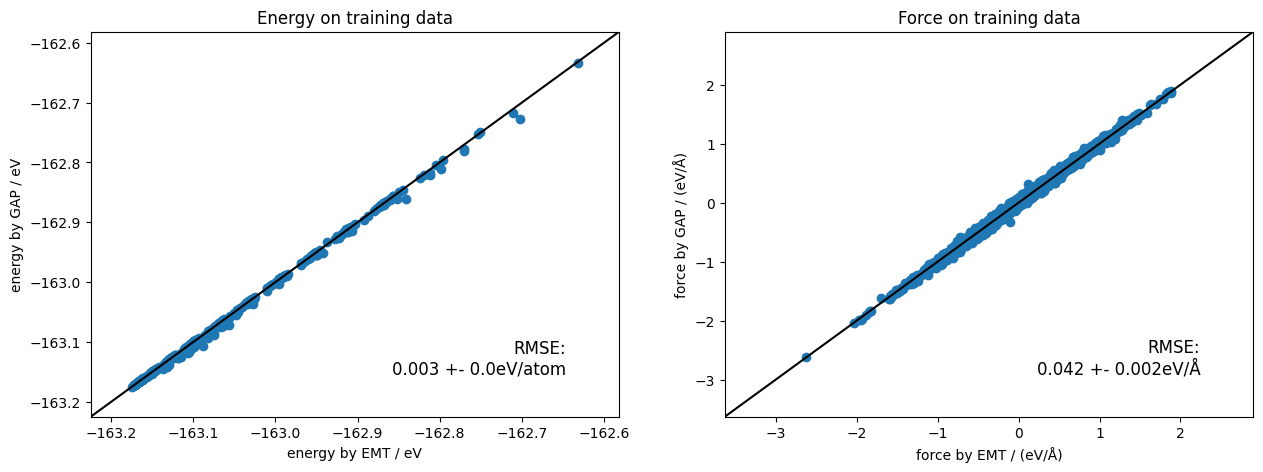

In [19]:
fig, ax_list = plt.subplots(nrows=1, ncols=2, gridspec_kw={'hspace': 0.3})
fig.set_size_inches(15, 5)
ax_list = ax_list.flat[:]

energy_plot('dia-gap-si-18.xyz', 'output.xyz', ax_list[0], 'Energy on training data')
force_plot('dia-gap-si-18.xyz', ax_list[1], 'Si', 'Force on training data')